# Adaptive GNN Aggregation – Results Analysis

This notebook:
1. Loads **synthetic benchmark** data (training data for the classifier) and **real benchmark** data.
2. Trains a **Random Forest classifier** to predict the best aggregation strategy per partition.
3. Computes **speedups** of the classifier (and oracle) vs. fixed-strategy baselines.
4. Generates publication-ready **figures and tables**.

In [1]:
# ============================================================
# CONFIGURATION — adjust these paths to your setup
# ============================================================

SYNTHETIC_CSV = "/home/pau/GNN/11/benchmarks/graphlaxy_5.csv"   # Output of Step 2
REAL_CSV      = "/home/pau/GNN/results/results1.csv"            # Output of Step 3
METRICS_DIR   = "/home/pau/GNN/11/metrics"                      # Partition metrics

# Features used by the classifier
FEATURES = [
    "out_dim", "feature_dim",
    "log_nodes", "log_density", "clustering", "max_degree_pct",
]

# Filters (should match the synthetic training data range)
MAX_NODES = 10_000
MAX_EDGES = 50_000

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
)

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 14,
    "axes.labelsize": 16, "axes.titlesize": 18,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 14,
})

COLOR_EDGE   = "#D35400"
COLOR_SPARSE = "#50C878"
COLOR_DENSE  = "#1F4788"

## 1. Load and merge data

In [3]:
# --- Real benchmark ---
df = pd.read_csv(REAL_CSV)
df.columns = df.columns.str.strip()
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()
print(f"Real benchmark: {len(df)} rows")
print(f"Datasets: {df['dataset'].unique()}")

# --- Partition metrics ---
metrics_list = []
for ds in df["dataset"].unique():
    path = f"{METRICS_DIR}/{ds}_partitions_metrics.csv"
    if os.path.exists(path):
        m = pd.read_csv(path)
        m["dataset"] = ds
        metrics_list.append(m)
        print(f"  {ds}: {len(m)} partitions")
    else:
        print(f"  {ds}: metrics NOT FOUND")

df_metrics = pd.concat(metrics_list, ignore_index=True)

# --- Merge ---
df["merge_key"] = df["dataset"] + "_" + df["partition_config"] + "_" + df["partition_name"]
df_metrics["merge_key"] = df_metrics["dataset"] + "_" + df_metrics["strategy_dir"] + "_" + df_metrics["partition_name"]
df_merged = df.merge(df_metrics, on="merge_key", how="left", suffixes=("", "_metrics"))
print(f"\nMerged: {len(df_merged)} rows ({df_merged['nodes'].isna().sum()} without metrics)")

Real benchmark: 11809 rows
Datasets: ['citeseer' 'cora' 'physics' 'pubmed' 'computers' 'flickr' 'ogbn_arxiv'
 'actor' 'corafull' 'elliptic']
  citeseer: 60 partitions
  cora: 60 partitions
  physics: 572 partitions
  pubmed: 60 partitions
  computers: 60 partitions
  flickr: 1263 partitions
  ogbn_arxiv: 4545 partitions
  actor: 60 partitions
  corafull: 60 partitions
  elliptic: 5070 partitions

Merged: 11809 rows (0 without metrics)


## 2. Feature engineering & classifier training

In [4]:
TIME_COLS = ["edge_median_time_s", "sparse_median_time_s", "dense_median_time_s"]

df_valid = df_merged.dropna(subset=TIME_COLS + ["nodes"]).copy()
df_valid["true_kernel"] = df_valid[TIME_COLS].idxmin(axis=1).str.replace("_median_time_s", "")
df_valid["T_oracle"] = df_valid[TIME_COLS].min(axis=1)

# --- Synthetic training data ---
df_train = pd.read_csv(SYNTHETIC_CSV)
TRAIN_TIME_COLS = ["step_s_edge_agg", "step_s_sparse_matmul", "step_s_dense_matmul"]

# --- Derive features in both sets ---
def add_features(d):
    d["log_nodes"] = np.log10(d["nodes"].clip(lower=1))
    d["log_edges"] = np.log10(d["edges"].clip(lower=1))
    d["avg_degree"] = 2.0 * d["edges"] / d["nodes"].clip(lower=1)
    d["imbalance"] = d["max_degree"] / d["avg_degree"].clip(lower=1e-9)
    d["log_density"] = np.log10(d["density"].clip(lower=1e-12))
    d["max_degree_pct"] = d["max_degree"] / (d["nodes"] - 1).clip(lower=1)
    return d

df_train = add_features(df_train)
df_valid = add_features(df_valid)

# Filter training data
mask_tr = df_train[FEATURES + TRAIN_TIME_COLS].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
df_train_clean = df_train[mask_tr].copy()
df_train_clean = df_train_clean[(df_train_clean["nodes"] <= MAX_NODES) &
                                (df_train_clean["edges"] <= MAX_EDGES)]
print(f"Training samples: {len(df_train_clean)}")

X_train = df_train_clean[FEATURES].values
y_train = (df_train_clean[TRAIN_TIME_COLS]
           .idxmin(axis=1)
           .str.replace("step_s_", "")
           .str.replace("_matmul", "")
           .str.replace("_agg", ""))

# --- Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=30, min_samples_split=2, min_samples_leaf=1,
    max_features="sqrt", class_weight="balanced", random_state=0, n_jobs=4,
)
rf.fit(X_train, y_train)
print("Classifier trained.")

Training samples: 458591
Classifier trained.


## 3. Predict on real data & compute speedups

In [5]:
# Filter real data
mask_r = df_valid[FEATURES].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
df_valid = df_valid[mask_r].copy()

# Remove configs where ANY partition exceeds limits
df_valid["_ck"] = df_valid["dataset"] + "_" + df_valid["partition_config"]
keep = df_valid.groupby("_ck").apply(
    lambda g: (g["nodes"] <= MAX_NODES).all() and (g["edges"] <= MAX_EDGES).all()
)
df_valid = df_valid[df_valid["_ck"].isin(keep[keep].index)].drop(columns=["_ck"]).copy()
print(f"Valid partitions after filtering: {len(df_valid)}")

# Predict
df_valid["pred_kernel"] = rf.predict(df_valid[FEATURES].values)
df_valid["T_model"] = np.where(
    df_valid["pred_kernel"] == "edge",   df_valid["edge_median_time_s"],
    np.where(df_valid["pred_kernel"] == "sparse", df_valid["sparse_median_time_s"],
             df_valid["dense_median_time_s"]))
df_valid["is_correct"] = df_valid["true_kernel"] == df_valid["pred_kernel"]

print(f"Global accuracy: {df_valid['is_correct'].mean():.1%}")

# --- Helper: per-configuration speedups ---
def config_speedups(df_subset, time_col="T_model"):
    """Group by config, sum partition times, compute speedups."""
    df_subset = df_subset.copy()
    df_subset["_cfg"] = df_subset["dataset"] + "_" + df_subset["partition_config"]
    g = df_subset.groupby("_cfg").agg({
        "edge_median_time_s": "sum", "sparse_median_time_s": "sum",
        "dense_median_time_s": "sum", time_col: "sum",
    })
    for base in ["edge", "sparse", "dense"]:
        g[f"speedup_vs_{base}"] = g[f"{base}_median_time_s"] / g[time_col]
    return g

Valid partitions after filtering: 11044
Global accuracy: 75.9%


## 4. Summary table (speedups by dataset)

In [6]:
header = f"{'Dataset':<12} | {'Acc':>6} | {'vs Edge (mean|med)':>25} | {'vs Sparse':>20} | {'vs Dense':>20}"
print(header)
print("-" * len(header))

all_sp = {b: [] for b in ["edge", "sparse", "dense"]}

for ds in sorted(df_valid["dataset"].unique()):
    dfd = df_valid[df_valid["dataset"] == ds]
    acc = dfd["is_correct"].mean() * 100
    sp = config_speedups(dfd)
    parts = []
    for b in ["edge", "sparse", "dense"]:
        mn = sp[f"speedup_vs_{b}"].mean()
        md = sp[f"speedup_vs_{b}"].median()
        parts.append(f"{mn:.3f}x|{md:.3f}x")
        all_sp[b].extend(sp[f"speedup_vs_{b}"].tolist())
    print(f"{ds:<12} | {acc:>5.1f}% | {parts[0]:>25} | {parts[1]:>20} | {parts[2]:>20}")

print("-" * len(header))
acc_t = df_valid["is_correct"].mean() * 100
parts_t = [f"{np.mean(all_sp[b]):.3f}x|{np.median(all_sp[b]):.3f}x" for b in ["edge", "sparse", "dense"]]
print(f"{'TOTAL':<12} | {acc_t:>5.1f}% | {parts_t[0]:>25} | {parts_t[1]:>20} | {parts_t[2]:>20}")

Dataset      |    Acc |        vs Edge (mean|med) |            vs Sparse |             vs Dense
-----------------------------------------------------------------------------------------------
actor        |  63.8% |             1.064x|1.028x |        1.034x|1.005x |        1.128x|1.079x
citeseer     |  75.0% |             1.048x|1.051x |        1.082x|1.066x |        1.080x|1.064x
computers    |  91.7% |             1.526x|1.524x |        0.989x|1.000x |        1.173x|1.165x
cora         |  68.3% |             1.061x|1.075x |        1.093x|1.122x |        1.000x|1.000x
corafull     | 100.0% |             3.389x|1.732x |        1.000x|1.000x |        4.624x|3.870x
elliptic     |  76.6% |             1.073x|1.046x |        1.315x|1.349x |        1.093x|1.000x
flickr       |  79.9% |             1.061x|1.039x |        1.242x|1.190x |        1.148x|1.021x
ogbn_arxiv   |  72.4% |             1.117x|1.107x |        1.351x|1.406x |        0.996x|1.000x
physics      |  86.7% |             5.50

## 5. Classification metrics & confusion matrix

              precision    recall  f1-score   support

        edge     0.7619    0.9743    0.8551      7484
      sparse     0.7874    0.1722    0.2826      2903
       dense     0.7053    0.8995    0.7906       657

    accuracy                         0.7591     11044
   macro avg     0.7515    0.6820    0.6428     11044
weighted avg     0.7652    0.7591    0.7008     11044



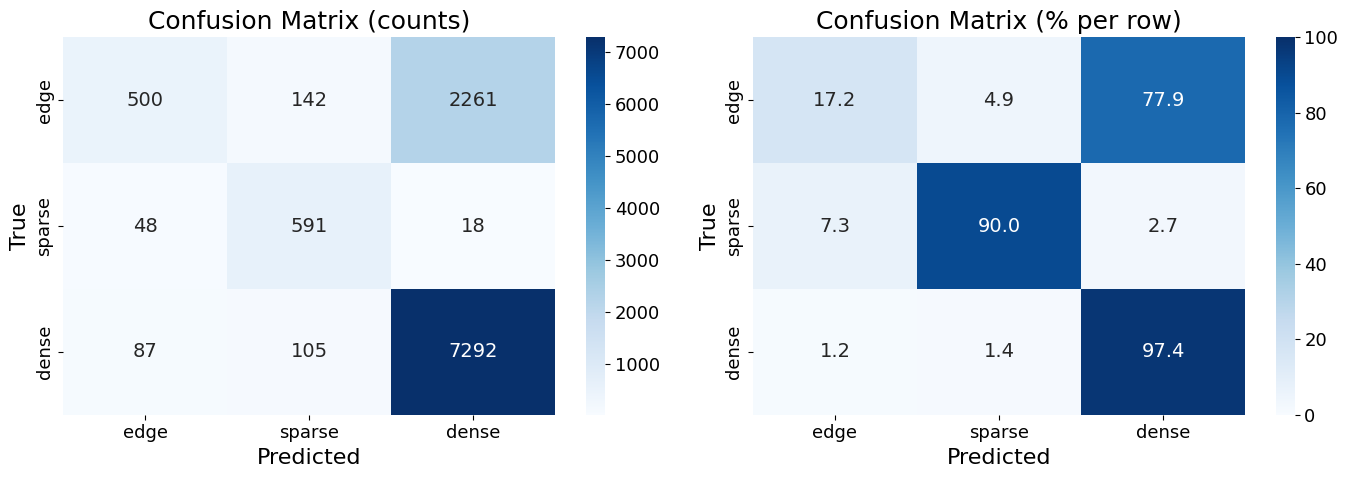

In [7]:
y_true = df_valid["true_kernel"]
y_pred = df_valid["pred_kernel"]
labels = ["edge", "sparse", "dense"]

print(classification_report(y_true, y_pred, target_names=labels, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax1)
ax1.set_title("Confusion Matrix (counts)"); ax1.set_ylabel("True"); ax1.set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax2,
            vmin=0, vmax=100)
ax2.set_title("Confusion Matrix (% per row)"); ax2.set_ylabel("True"); ax2.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## 6. Speedup boxplots by dataset

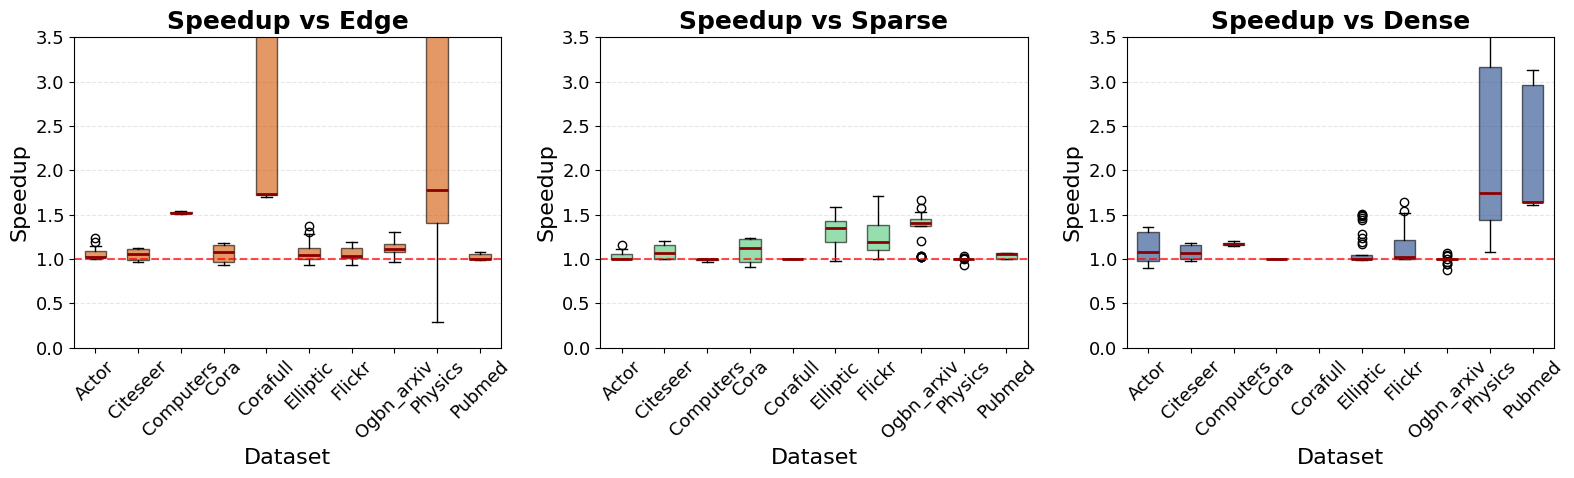

In [8]:
rows_bp = []
for ds in sorted(df_valid["dataset"].unique()):
    sp = config_speedups(df_valid[df_valid["dataset"] == ds])
    for _, r in sp.iterrows():
        for b in ["Edge", "Sparse", "Dense"]:
            rows_bp.append({"Dataset": ds, "Baseline": b,
                            "Speedup": r[f"speedup_vs_{b.lower()}"]})

df_bp = pd.DataFrame(rows_bp)
baselines = ["Edge", "Sparse", "Dense"]
colors = [COLOR_EDGE, COLOR_SPARSE, COLOR_DENSE]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, bl, col in zip(axes, baselines, colors):
    sub = df_bp[df_bp["Baseline"] == bl]
    datasets_sorted = sorted(sub["Dataset"].unique())
    data = [sub[sub["Dataset"] == d]["Speedup"].values for d in datasets_sorted]
    bp = ax.boxplot(data, labels=[d.capitalize() for d in datasets_sorted], patch_artist=True,
                    medianprops=dict(color="darkred", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.6))
    ax.axhline(1.0, color="red", ls="--", lw=1.5, alpha=0.7)
    ax.set_title(f"Speedup vs {bl}", fontsize=18, fontweight="bold")
    ax.set_xlabel("Dataset"); ax.set_ylabel("Speedup")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3, ls="--")
    ax.set_ylim(0, 3.5)

plt.tight_layout()
plt.show()

## 7. Feature importance

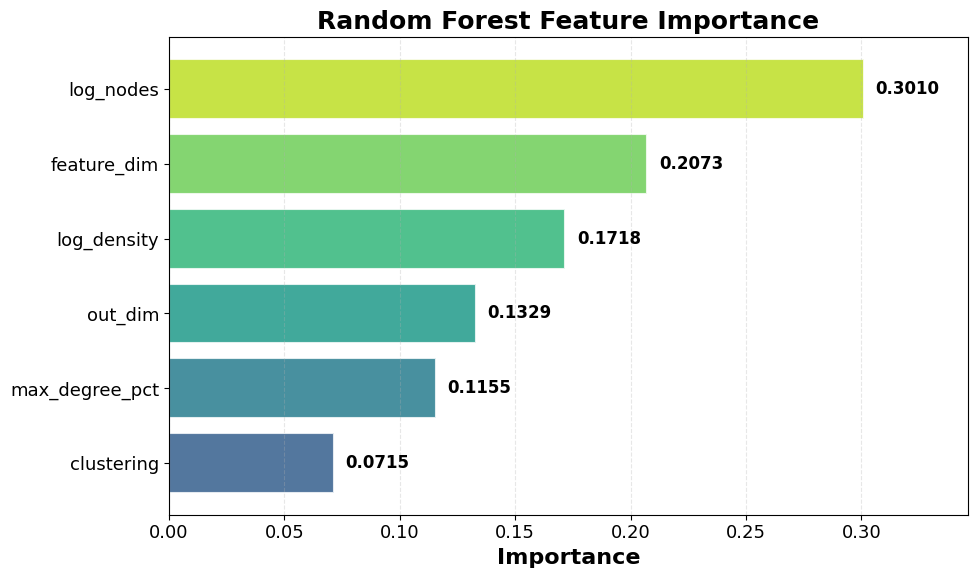

       Feature  Importance  Cumulative
     log_nodes    0.301001    0.301001
   feature_dim    0.207317    0.508317
   log_density    0.171757    0.680074
       out_dim    0.132891    0.812965
max_degree_pct    0.115513    0.928478
    clustering    0.071522    1.000000


In [9]:
imp = pd.DataFrame({"Feature": FEATURES, "Importance": rf.feature_importances_})
imp = imp.sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, len(imp)))
bars = ax.barh(imp["Feature"], imp["Importance"], color=colors_fi, edgecolor="white", lw=1.5, alpha=0.85)
for bar, v in zip(bars, imp["Importance"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance", fontsize=16, fontweight="bold")
ax.set_title("Random Forest Feature Importance", fontsize=18, fontweight="bold")
ax.grid(axis="x", alpha=0.3, ls="--")
ax.set_xlim(0, imp["Importance"].max() * 1.15)
plt.tight_layout()
plt.show()

# Cumulative importance
imp_desc = imp.sort_values("Importance", ascending=False)
imp_desc["Cumulative"] = imp_desc["Importance"].cumsum()
print(imp_desc.to_string(index=False))

## 8. Heterogeneity analysis

Configs analysed: 211
Oracle beats all 3 baselines: 99/211 (46.9%)


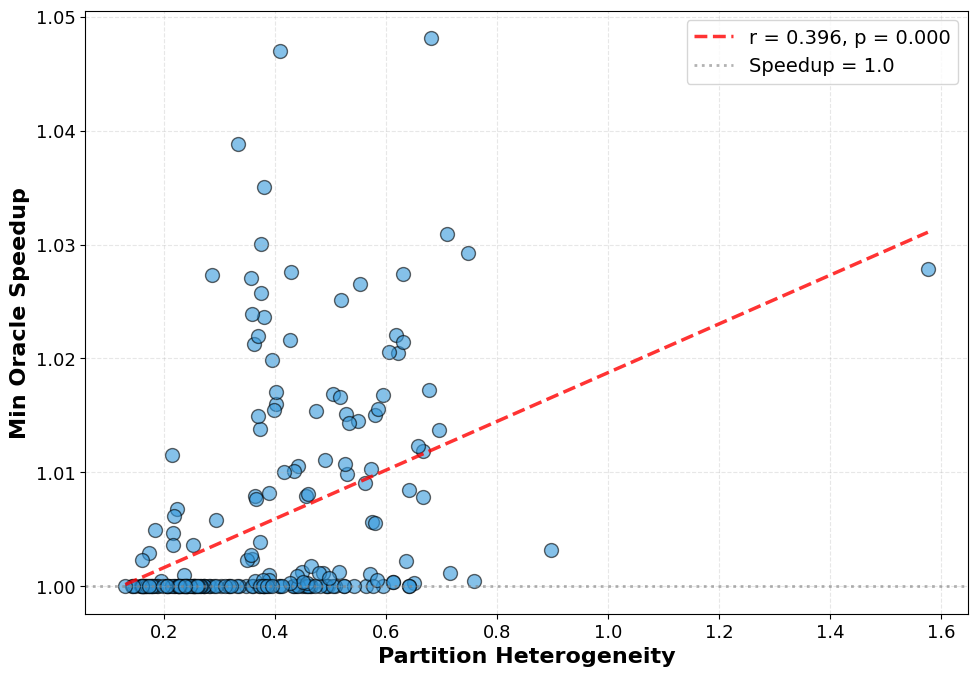

In [10]:
from scipy.stats import pearsonr, mannwhitneyu

het_rows = []
for ds in sorted(df_valid["dataset"].unique()):
    dfd = df_valid[df_valid["dataset"] == ds]
    for cfg in dfd["partition_config"].unique():
        dfc = dfd[dfd["partition_config"] == cfg]
        if len(dfc) < 2:
            continue
        cvs = []
        for f in ["nodes", "density", "clustering", "max_degree"]:
            if f in dfc.columns and dfc[f].mean() > 0:
                cvs.append(dfc[f].std() / dfc[f].mean())
        het = np.mean(cvs) if cvs else 0.0

        # Oracle speedups for this config
        t_e = dfc["edge_median_time_s"].sum()
        t_s = dfc["sparse_median_time_s"].sum()
        t_d = dfc["dense_median_time_s"].sum()
        t_o = dfc["T_oracle"].sum()
        s_e, s_s, s_d = t_e / t_o, t_s / t_o, t_d / t_o
        het_rows.append({
            "dataset": ds, "config": cfg, "heterogeneity": het,
            "speedup_vs_edge": s_e, "speedup_vs_sparse": s_s, "speedup_vs_dense": s_d,
            "min_speedup": min(s_e, s_s, s_d),
            "beats_all": (s_e > 1) and (s_s > 1) and (s_d > 1),
        })

df_het = pd.DataFrame(het_rows)

print(f"Configs analysed: {len(df_het)}")
print(f"Oracle beats all 3 baselines: {df_het['beats_all'].sum()}/{len(df_het)} "
      f"({df_het['beats_all'].mean():.1%})")

# Scatter: heterogeneity vs min oracle speedup
r, p = pearsonr(df_het["heterogeneity"], df_het["min_speedup"])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_het["heterogeneity"], df_het["min_speedup"],
           s=100, alpha=0.6, edgecolors="black", color="#3498db")
z = np.polyfit(df_het["heterogeneity"], df_het["min_speedup"], 1)
x_line = np.linspace(df_het["heterogeneity"].min(), df_het["heterogeneity"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), "--r", lw=2.5, alpha=0.8,
        label=f"r = {r:.3f}, p = {p:.3f}")
ax.axhline(1.0, color="gray", ls=":", lw=2, alpha=0.6, label="Speedup = 1.0")
ax.set_xlabel("Partition Heterogeneity", fontsize=16, fontweight="bold")
ax.set_ylabel("Min Oracle Speedup", fontsize=16, fontweight="bold")
ax.legend(fontsize=14); ax.grid(True, alpha=0.3, ls="--")
plt.tight_layout()
plt.show()

## 9. Configurations with speedup > 1.0× in all baselines

In [11]:
for label, time_col in [("MODEL", "T_model"), ("ORACLE", "T_oracle")]:
    print(f"\n{'='*80}")
    print(f"Configs where {label} beats ALL 3 baselines (speedup > 1.0x)")
    print("=" * 80)

    total_hits = 0
    for ds in sorted(df_valid["dataset"].unique()):
        sp = config_speedups(df_valid[df_valid["dataset"] == ds], time_col=time_col)
        hits = sp[(sp["speedup_vs_edge"] > 1) & (sp["speedup_vs_sparse"] > 1) & (sp["speedup_vs_dense"] > 1)]
        if len(hits) > 0:
            hits = hits.copy()
            hits["avg"] = (hits["speedup_vs_edge"] + hits["speedup_vs_sparse"] + hits["speedup_vs_dense"]) / 3
            hits = hits.sort_values("avg", ascending=False)
            print(f"\n  {ds.upper()}: {len(hits)}/{len(sp)} configs")
            for idx, row in hits.head(5).iterrows():
                print(f"    {idx:<30} edge={row['speedup_vs_edge']:.3f}x  "
                      f"sparse={row['speedup_vs_sparse']:.3f}x  dense={row['speedup_vs_dense']:.3f}x")
            total_hits += len(hits)
        else:
            print(f"\n  {ds.upper()}: 0/{len(sp)} configs")

    print(f"\n  Total: {total_hits} configs with {label} speedup in all 3 baselines")


Configs where MODEL beats ALL 3 baselines (speedup > 1.0x)

  ACTOR: 3/19 configs
    actor_kahip_strong_k4          edge=1.028x  sparse=1.114x  dense=1.022x
    actor_kahip_eco_k4             edge=1.023x  sparse=1.083x  dense=1.002x
    actor_metis_edges+centrality_k4 edge=1.004x  sparse=1.054x  dense=1.010x

  CITESEER: 0/20 configs

  COMPUTERS: 0/3 configs

  CORA: 0/20 configs

  CORAFULL: 0/13 configs

  ELLIPTIC: 4/40 configs
    elliptic_metis_nodes+edges+centrality_k64 edge=1.144x  sparse=1.430x  dense=1.000x
    elliptic_metis_nodes+edges_k64 edge=1.019x  sparse=1.462x  dense=1.001x
    elliptic_metis_edges_k256      edge=1.008x  sparse=1.249x  dense=1.000x
    elliptic_metis_nodes+edges_k256 edge=1.036x  sparse=1.157x  dense=1.000x

  FLICKR: 8/20 configs
    flickr_metis_edges_k16         edge=1.071x  sparse=1.008x  dense=1.643x
    flickr_kahip_fast_k16          edge=1.020x  sparse=1.022x  dense=1.513x
    flickr_metis_nodes_k16         edge=1.118x  sparse=1.001x  dense=1